In [1]:
import astropy as ap
import cupy as cp
import gala
import matplotlib.pyplot as plt
import numpy as np
import os

from astropy import units as u
from astropy import constants as apc
from gala import potential as gp
from gala import dynamics as gd
from IPython import display
from time import time
from tqdm import trange

os.environ['CUPY_DUMP_CUDA_SOURCE_ON_ERROR'] = '1'

In [2]:
G = apc.G.to(u.kpc**3 / u.yr**2 / u.solMass)
G_flt = float(G * u.yr**2 * u.solMass / u.kpc**3)
dt = 1e-4

accel = cp.RawKernel(r'''
extern "C" __global__
void accel(const double q[3], double a[3]) {
    double G = %s;
    double solar_mass = 1.;
    
    double r = sqrt(q[0]*q[0] + q[1]*q[1] + q[2]*q[2]);
    for (int j = 0; j < 3; j++) {
        a[j] = -G * solar_mass * q[j] / (r*r*r);
    }
}
''' % (G_flt,), 'accel')


def time_step(q, v):
    # position calculation
    a1 = cp.zeros_like(q)
    accel((1,), (1,), (q, a1))
    q_out = q + v * dt + dt**2/2 * a1
    
    # velocity calculation
    a2 = cp.zeros_like(q)
    accel((1,), (1,), (q_out, a2))
    v_out = v + dt/2 * (a1 + a2)
    
    return (q_out, v_out)

In [15]:
# initial conditions: Earth at perihelion (y=0, v_x=0)
perihelion = float((147_105_052 * u.km).to(u.kpc) / u.kpc)
orbital_velocity = float((30.29 * u.km / u.s).to(u.kpc / u.yr) * u.yr / u.kpc)
m_earth = float(apc.M_earth.to(u.solMass) / u.solMass)

# q_init = cp.array([ perihelion, 0., 0., 0., orbital_velocity, 0. ])
q0 = cp.array([ perihelion, 0., 0. ])
v0 = cp.array([ 0., orbital_velocity, 0.])

T = 5e1
N_pts = int(T/dt)
ts = np.arange(0, T, dt)
qs = cp.zeros((N_pts+1, 3))
vs = cp.zeros((N_pts+1, 3))
qs[0] = q0
vs[0] = v0
q = q0
v = v0

start_time = time()
for i in trange(N_pts):
    q, v = time_step(q, v)
    qs[i+1] = q
    vs[i+1] = v
        
print(f'Total time: {time() - start_time:.0f}s')
qs = cp.asnumpy(qs)
vs = cp.asnumpy(vs)

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 500000/500000 [01:13<00:00, 6803.62it/s]

Total time: 73s


In [4]:
init = np.array([[perihelion, 0., 0.], [0., orbital_velocity, 0.]])
kepler_potential = gp.KeplerPotential(m=1. * u.solMass, units=gala.units.solarsystem)

def F(t, q):
    x, x_dot = q
    x_ddot = (kepler_potential.acceleration(x*u.kpc).to(u.kpc/u.yr**2)*u.yr**2/u.kpc).reshape((3,))
    return np.array([x_dot, x_ddot], dtype=object)

integrator = gala.integrate.LeapfrogIntegrator(F)
start_time = time()
orbit = integrator.run(init, dt=dt, n_steps=T/dt)
time() - start_time

389.3481662273407

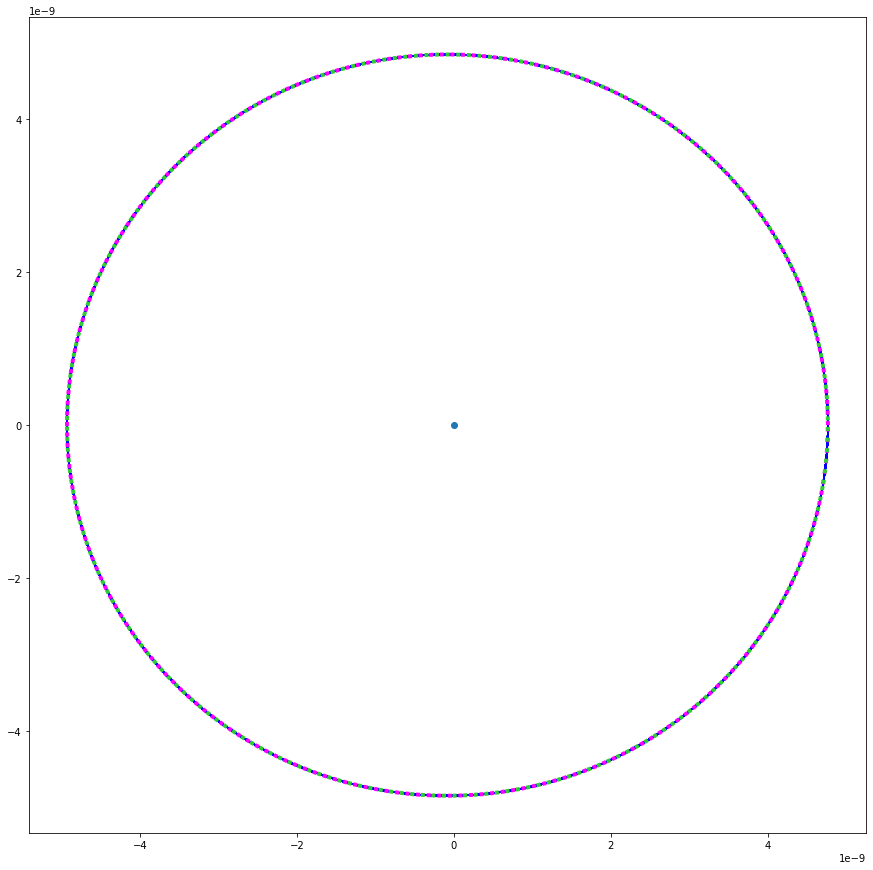

In [5]:
plt.figure(figsize=(15, 15))
plt.plot(qs[:, 0], qs[:, 1], 'b--')
plt.plot(qs[:10000, 0], qs[:10000, 1], ':', c='magenta', lw=4)
plt.plot(qs[-10000:, 0], qs[-10000:, 1], ':', c='limegreen', lw=4)
plt.scatter(0, 0)

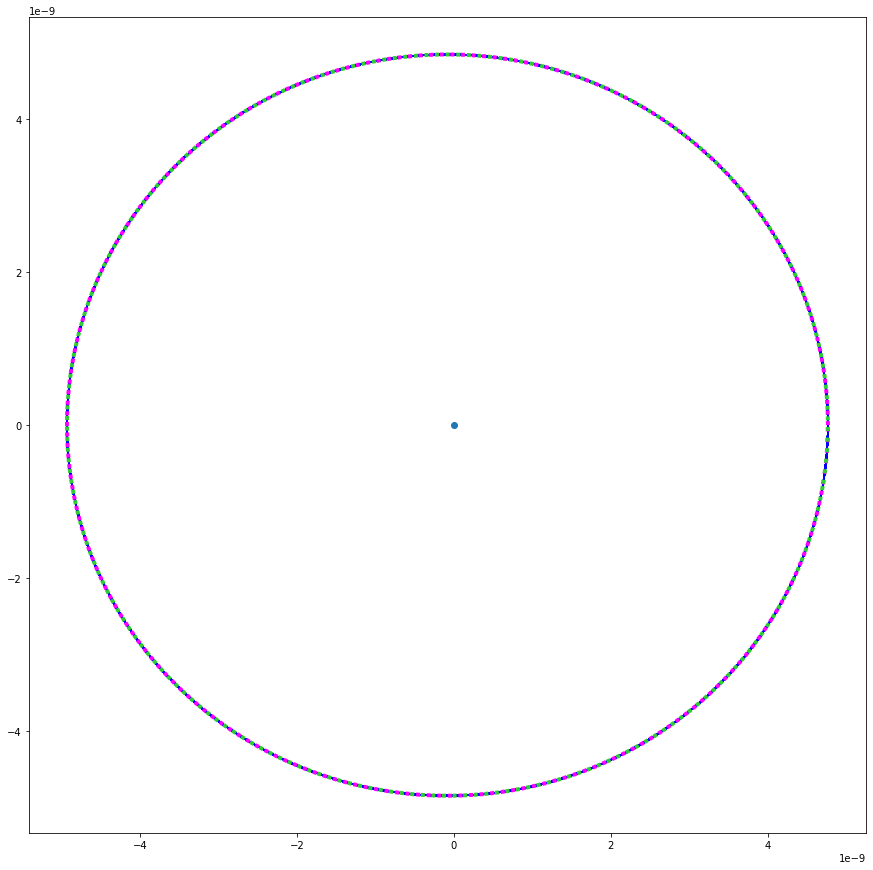

In [6]:
poss = orbit.pos[:].get_xyz()[0]
plt.figure(figsize=(15, 15))
plt.plot(poss[:, 0], poss[:, 1], 'b--')
plt.plot(poss[:10000, 0], poss[:10000, 1], ':', c='magenta', lw=4)
plt.plot(poss[-10000:, 0], poss[-10000:, 1], ':', c='limegreen', lw=4)
plt.scatter(0, 0)

In [11]:
start_time = time()
qs = cp.asnumpy(qs)
vs = cp.asnumpy(vs)
Es = (vs[:, 0]**2 + vs[:, 1]**2 + vs[:, 2]**2)/2 - G_flt / np.sqrt(qs[:, 0]**2 + qs[:, 1]**2 + qs[:, 2]**2)

avg = sum(Es)/N_pts
max_deviation = max(max(Es) - avg, avg - min(Es))/(-avg)
print(f'Maximum energy deviation of the system: {max_deviation}')
time() - start_time

Maximum energy deviation of the system: 2.0032073273902435e-06


0.16268110275268555

In [12]:
start_time = time()
vels = orbit.vel[:].get_d_xyz()[0]
Eps = (vels[:, 0]**2 + vels[:, 1]**2 + vels[:, 2]**2)/2 - G_flt / np.sqrt(poss[:, 0]**2 + poss[:, 1]**2 + poss[:, 2]**2)

avg = sum(Eps)/N_pts
max_deviation = max(max(Eps) - avg, avg - min(Eps))/(-avg)
print(f'Maximum energy deviation of the system: {max_deviation}')
time() - start_time

Maximum energy deviation of the system: 2.003207386071358e-06


22.715903759002686

In [14]:
deviation = abs(qs[:, :3] - poss)
ix = np.where(deviation == max(deviation[:, 0]))[0][0]
iy = np.where(deviation == max(deviation[:, 1]))[0][0]
print(f'Maximum deviation in the x-position: {abs(deviation[ix, 0]/poss[ix, 0])}')
print(f'Maximum deviation in the y-position: {abs(deviation[iy, 1]/poss[iy, 1])}')

Maximum deviation in the x-position: 1.0330511965468512e-07
Maximum deviation in the y-position: 1.6628494828217145e-10
